# Binary Classification of Non-Linear Data (Moons)

This notebook demonstrates the capabilities of the `ml-engine-from-scratch` framework on a classic non-linear problem: the *Moons* dataset. 

Unlike linearly separable blobs, the intertwined shapes of this dataset require a deep neural network capable of learning highly non-linear decision boundaries. We will build a Multi-Layer Perceptron (MLP), train it using our custom `Adam` optimizer and `BinaryCrossEntropyLoss`, and visualize the results.

In [1]:
import ml_framework as ml
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
import numpy as np

# General Configuration
N_SAMPLES = 2000
RANDOM_SEED = 42
NOISE = 0.12
IN_FEATURES = 2
OUT_FEATURES = 1
LEARNING_RATE = 0.001
TEST_SIZE = 0.2

rng = np.random.default_rng(seed=RANDOM_SEED)

## 1. Data Generation and Preparation
We use scikit-learn's `make_moons` function to generate 2,000 data points forming two interleaving half-circles. We add a bit of statistical noise to make the classification task more realistic and challenging.

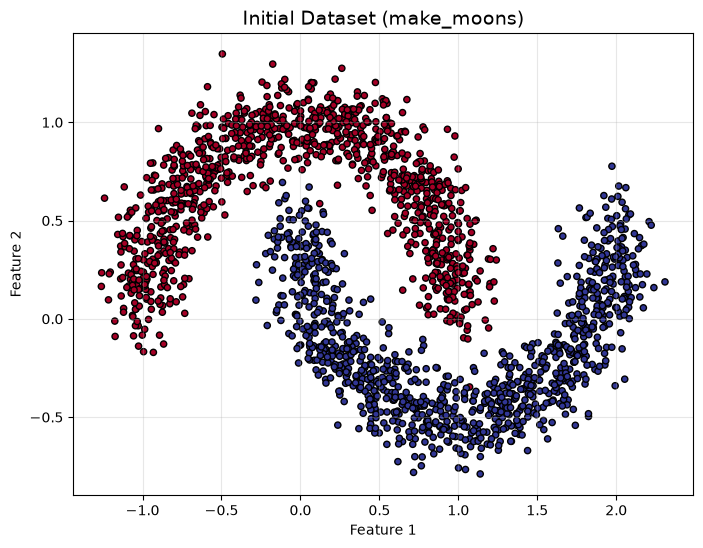

Training features shape: (1600, 2)
Training labels shape: (1600, 1)
Testing features shape: (400, 2)


In [2]:
# Generate the data
x_data, y_data = make_moons(n_samples=N_SAMPLES, shuffle=True, noise=NOISE, random_state=RANDOM_SEED)
y_data = y_data.reshape(-1, 1)

# Initial Visualization of the Raw Data
plt.figure(figsize=(8, 6))
plt.title("Initial Dataset (make_moons)", fontsize=14)
plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data.flatten(), s=20, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=TEST_SIZE, random_state=RANDOM_SEED)

print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")

## 2. Neural Network Architecture
We build an MLP with two hidden layers.

*Engineering Note: Unlike the linearly separable `make_blobs` dataset, the `make_moons` dataset is highly non-linear. If we were to omit the `ReLU` activation functions here, the network would mathematically collapse into a single linear transformation, making it completely impossible to separate the two moons. The `ReLU` layers are strictly mandatory here to give the network its non-linear expressive power.*

In [3]:
hidden_size1 = 32
hidden_size2 = 32

# Create the model using our Sequential API
model = ml.Sequential([
    ml.LinearLayer(in_features=IN_FEATURES, out_features=hidden_size1, rng=rng),
    ml.ActivationLayer(func=ml.ReLU, derivative=ml.ReLUDerivative),

    ml.LinearLayer(in_features=hidden_size1, out_features=hidden_size2, rng=rng),
    ml.ActivationLayer(func=ml.ReLU, derivative=ml.ReLUDerivative),

    ml.LinearLayer(in_features=hidden_size2, out_features=OUT_FEATURES, rng=rng)
])

print("Model Architecture Initialized:")
print(model)

# Create the loss function and optimizer
loss_fn = ml.BinaryCrossEntropyLoss()
optimizer = ml.Adam(learning_rate=LEARNING_RATE)

Model Architecture Initialized:
Sequential(
	(0): LinearLayer(in_features=2, out_features=32, bias=True)
	(1): ActivationLayer(func=ReLU)
	(2): LinearLayer(in_features=32, out_features=32, bias=True)
	(3): ActivationLayer(func=ReLU)
	(4): LinearLayer(in_features=32, out_features=1, bias=True)
)


## 3. Model Training
We train the model over 40 epochs using mini-batches. During the forward pass, the model outputs raw logits. To compute the training and testing accuracy, we pass these logits through a `Sigmoid` function and round the result to get discrete class predictions (0 or 1).

In [4]:
EPOCHS = 40
TEST_FREQ = 10
BATCH_SIZE = 32

train_loss_history, test_loss_history = [], []
train_accuracy_history, test_accuracy_history = [], []

for epoch in range(EPOCHS):
    model.train()

    # Batch creation and Shuffling
    indices = np.arange(0, X_train.shape[0])
    rng.shuffle(indices)

    avg_train_loss = 0
    avg_train_accuracy = 0
    
    for start_idx in range(0, X_train.shape[0], BATCH_SIZE):
        X_train_batch = X_train[indices[start_idx:start_idx+BATCH_SIZE]]
        y_train_batch = y_train[indices[start_idx:start_idx+BATCH_SIZE]]

        # Forward pass
        y_logits = model(X_train_batch)
        y_pred = np.round(ml.Sigmoid(y_logits))

        # Compute the loss and accuracy
        avg_train_loss += loss_fn(logits=y_logits, y_expected=y_train_batch)
        avg_train_accuracy += (np.sum(y_train_batch == y_pred) / BATCH_SIZE) * 100

        # Backpropagation
        model.backward(loss_fn.backward())

        # Optimizer step
        optimizer.step(model)

    n_batchs = int(len(X_train) / BATCH_SIZE)
    avg_train_loss /= n_batchs
    avg_train_accuracy /= n_batchs

    # Evaluation phase
    if epoch % TEST_FREQ == 0 or epoch == EPOCHS-1 or epoch == 0:
        model.eval()
        test_logits = model(X_test)
        test_loss = loss_fn(logits=test_logits, y_expected=y_test)
        
        y_test_pred = np.round(ml.Sigmoid(test_logits))
        test_accuracy = (np.sum(y_test == y_test_pred) / y_test.shape[0]) * 100

        train_loss_history.append(avg_train_loss)
        test_loss_history.append(test_loss)
        train_accuracy_history.append(avg_train_accuracy)
        test_accuracy_history.append(test_accuracy)

        print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_accuracy:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

Epoch 00 | Train Loss: 0.5687 | Train Acc: 71.31% | Test Loss: 0.4411 | Test Acc: 84.50%
Epoch 10 | Train Loss: 0.1137 | Train Acc: 96.06% | Test Loss: 0.1061 | Test Acc: 96.00%
Epoch 20 | Train Loss: 0.0347 | Train Acc: 99.38% | Test Loss: 0.0349 | Test Acc: 99.25%
Epoch 30 | Train Loss: 0.0164 | Train Acc: 99.81% | Test Loss: 0.0157 | Test Acc: 99.50%
Epoch 39 | Train Loss: 0.0124 | Train Acc: 99.75% | Test Loss: 0.0140 | Test Acc: 99.75%


## 4. Learning Curves: Loss and Accuracy
Visualizing the training metrics is critical to confirm that our custom backpropagation and optimizer are working smoothly, and to monitor for any signs of overfitting.

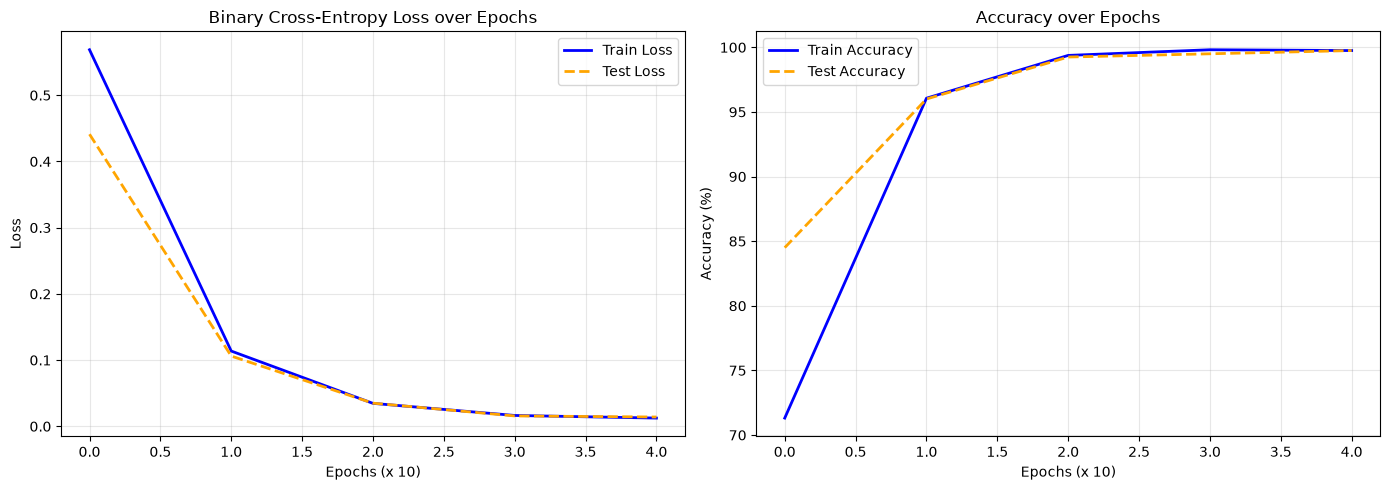

In [5]:
# Create a figure with two side-by-side subplots
plt.figure(figsize=(14, 5))

# Plot 1: Loss over Epochs
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss', color='blue', linewidth=2)
plt.plot(test_loss_history, label='Test Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Binary Cross-Entropy Loss over Epochs', fontsize=12)
plt.xlabel(f'Epochs (x {TEST_FREQ})', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Accuracy over Epochs
plt.subplot(1, 2, 2)
plt.plot(train_accuracy_history, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(test_accuracy_history, label='Test Accuracy', color='orange', linewidth=2, linestyle='--')
plt.title('Accuracy over Epochs', fontsize=12)
plt.xlabel(f'Epochs (x {TEST_FREQ})', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Decision Boundary Visualization
Finally, we generate a 2D mesh grid to visualize exactly how the neural network has warped space to separate the two intertwined moons. We plot this for both the training and testing sets side-by-side.

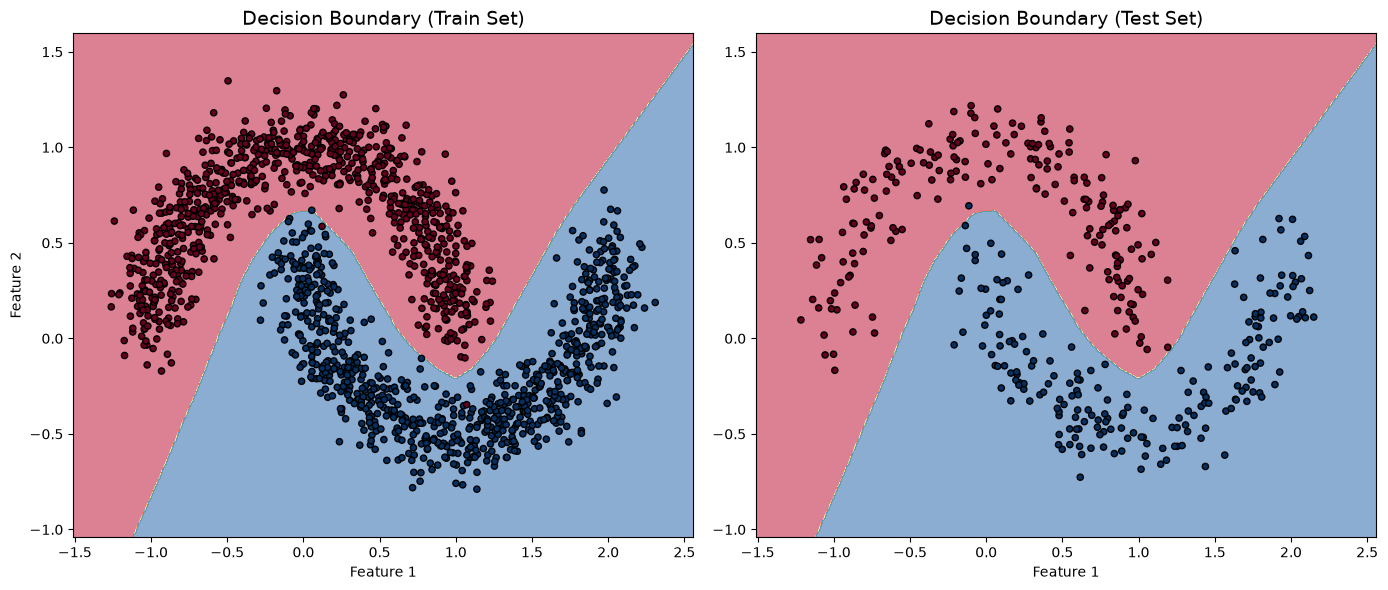

In [6]:
# Let's plot the decision boundary!
X = np.linspace(x_data[:,0].min() - 0.25, x_data[:,0].max() + 0.25, 500).reshape(-1,1)
Y = np.linspace(x_data[:,1].min() - 0.25, x_data[:,1].max() + 0.25, 500).reshape(-1,1)

xx, yy = np.meshgrid(X, Y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

model.eval()
grid_logits = model(grid_points)
grid_pred = np.round(ml.Sigmoid(grid_logits))

plt.figure(figsize=(14, 6))

# Subplot 1: Train Set
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, grid_pred.reshape(xx.shape), cmap=plt.cm.Spectral, alpha=0.6)
plt.scatter(x=X_train[:,0], y=X_train[:,1], c=y_train.flatten(), s=20, cmap=plt.cm.RdBu, edgecolors='k')
plt.title("Decision Boundary (Train Set)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Subplot 2: Test Set
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, grid_pred.reshape(xx.shape), cmap=plt.cm.Spectral, alpha=0.6)
plt.scatter(x=X_test[:,0], y=X_test[:,1], c=y_test.flatten(), s=20, cmap=plt.cm.RdBu, edgecolors='k')
plt.title("Decision Boundary (Test Set)", fontsize=14)
plt.xlabel("Feature 1")

plt.tight_layout()
plt.show()

## 6. Conclusion
The network successfully solved the non-linear classification problem, curving its decision boundary perfectly through the gap between the two moons. 

This notebook proves the mathematical completeness of our `ml-engine-from-scratch` framework: 
1. The **`ReLU` layers** correctly broke the linearity, enabling complex feature representation.
2. The **`BinaryCrossEntropyLoss`** and internal **backpropagation engine** reliably propagated gradients through multiple layers.
3. The **`Adam` optimizer** converged smoothly without getting trapped in local minima, as evidenced by the stable learning curves.